# Rossmann Retail Sales Analytics

## Project Objective

This project analyses how retail sales vary across weekdays, promotions, holidays, school holidays, and store types.

**Business question:** How can observed sales patterns support staffing, promotion planning, and store-level decisions?

The analysis focuses on descriptive and diagnostic business analytics rather than predictive modelling. It covers:

1. Sales overview and key performance indicators
2. Weekday sales patterns
3. Promotion uplift
4. State and school holiday effects
5. Store and store-type comparison
6. Business recommendations and limitations

The analysis uses open-store days for sales comparisons so that closed stores with zero sales do not distort the averages.

## 1. Data Loading and Preparation

The source file contains daily sales, customer counts, promotion flags, holiday indicators, and store characteristics. Sales per customer is added as a productivity KPI.

The file is searched for in the current working directory and in the project folder so the notebook can run from either location.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='pastel')

data_candidates = [
    Path('top20_stores_with_info.csv'),
    Path('ADS/ADS1002 Group/top20_stores_with_info.csv')
]

data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        'top20_stores_with_info.csv was not found. Update data_candidates with its location.'
    )

sales = pd.read_csv(data_path)
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)
sales['DayOfWeek'] = pd.to_numeric(sales['DayOfWeek'], errors='coerce').astype('Int64')
sales['Sales'] = pd.to_numeric(sales['Sales'], errors='coerce')
sales['Customers'] = pd.to_numeric(sales['Customers'], errors='coerce')
sales['Open'] = pd.to_numeric(sales['Open'], errors='coerce').fillna(0).astype(int)
sales['Promo'] = pd.to_numeric(sales['Promo'], errors='coerce').fillna(0).astype(int)
sales['SchoolHoliday'] = pd.to_numeric(sales['SchoolHoliday'], errors='coerce').fillna(0).astype(int)
sales['StateHoliday'] = sales['StateHoliday'].fillna('0').astype(str).replace({'0.0': '0'})

holiday_labels = {
    '0': 'No Holiday',
    'a': 'Public Holiday',
    'b': 'Easter',
    'c': 'Christmas'
}
sales['HolidayType'] = sales['StateHoliday'].map(holiday_labels).fillna(sales['StateHoliday'])
sales['SalesPerCustomer'] = sales['Sales'].div(sales['Customers'].replace(0, np.nan))
open_sales = sales.loc[sales['Open'].eq(1)].copy()

print('Source file:', data_path)
print('Rows:', len(sales))
print('Stores:', sales['Store'].nunique())
print('Date range:', sales['Date'].min().date(), 'to', sales['Date'].max().date())
print('Open-day rows:', len(open_sales))

Source file: top20_stores_with_info.csv
Rows: 201602
Stores: 223
Date range: 2013-01-01 to 2015-07-31
Open-day rows: 166619


## 2. Sales Overview

These KPIs establish the scale of the selected-store dataset and provide a reference point for the comparisons that follow.

In [2]:
total_sales = open_sales['Sales'].sum()
total_customers = open_sales['Customers'].sum()

overview_kpis = pd.DataFrame({
    'Metric': [
        'Total sales on open days',
        'Total customers on open days',
        'Average sales per open store-day',
        'Average customers per open store-day',
        'Sales per customer',
        'Open-day rate'
    ],
    'Value': [
        total_sales,
        total_customers,
        open_sales['Sales'].mean(),
        open_sales['Customers'].mean(),
        total_sales / total_customers,
        sales['Open'].mean()
    ]
})

overview_kpis

,Metric,Value
0,Total sales on open days,1.124471e+09
1,Total customers on open days,9.814321e+07
2,Average sales per open store-day,6.748753e+03
3,Average customers per open store-day,5.890277e+02
4,Sales per customer,1.145745e+01
5,Open-day rate,8.264749e-01


## 3. Weekday Pattern

Weekday comparisons show when stores experience higher demand and when staffing or inventory can potentially be reduced. The summary includes both sales volume and sales per customer.

In [3]:
weekday_order = [1, 2, 3, 4, 5, 6, 7]
weekday_labels = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

weekday_summary = (
    open_sales.groupby('DayOfWeek')
    .agg(
        Average_Sales=('Sales', 'mean'),
        Average_Customers=('Customers', 'mean'),
        Sales_per_Customer=('SalesPerCustomer', 'mean'),
        Open_Store_Days=('Sales', 'size')
    )
    .reindex(weekday_order)
    .rename_axis('DayOfWeek')
    .reset_index()
)
weekday_summary['Day'] = weekday_summary['DayOfWeek'].map(weekday_labels)
weekday_summary['Sales_Index_vs_Overall_%'] = (
    weekday_summary['Average_Sales'] / open_sales['Sales'].mean() - 1
) * 100

weekday_summary[
    [
        'DayOfWeek',
        'Day',
        'Average_Sales',
        'Average_Customers',
        'Sales_per_Customer',
        'Sales_Index_vs_Overall_%',
        'Open_Store_Days'
    ]
].round(2)

,DayOfWeek,Day,Average_Sales,Average_Customers,Sales_per_Customer,Sales_Index_vs_Overall_%,Open_Store_Days
0,1,Monday,8200.15,673.90,11.94,21.51,27265.0
1,2,Tuesday,6793.14,584.00,11.54,0.66,28552.0
2,3,Wednesday,6454.57,563.13,11.41,-4.36,28154.0
3,4,Thursday,6536.68,581.50,11.21,-3.14,26571.0
4,5,Friday,6932.15,614.74,11.26,2.72,27487.0
5,6,Saturday,5630.77,520.88,10.75,-16.57,28590.0
6,7,Sunday,NaN,NaN,NaN,NaN,NaN


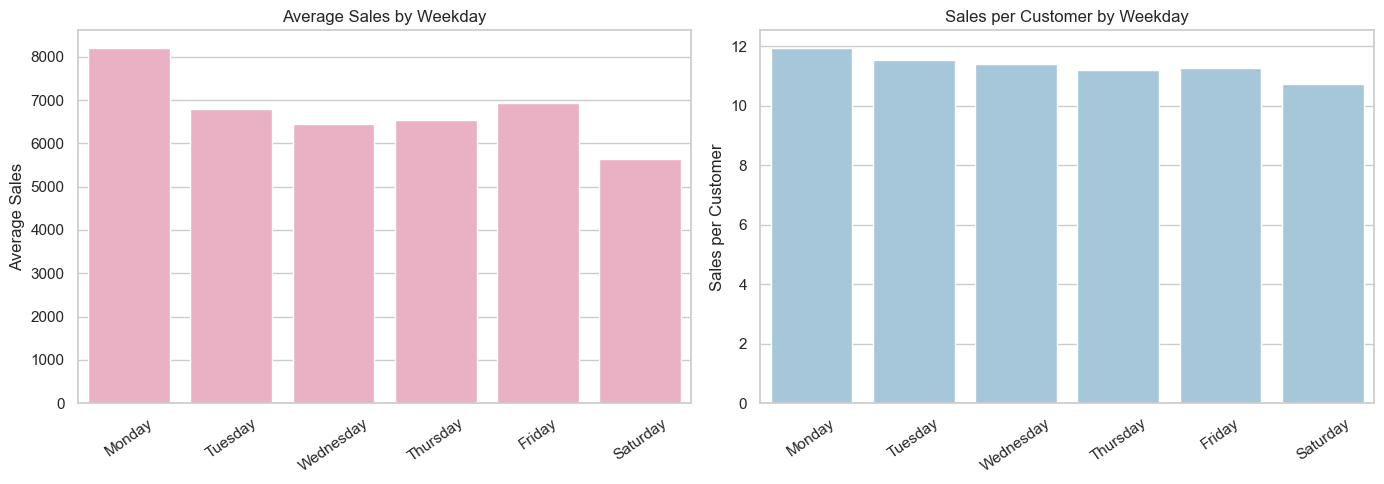

In [4]:
plot_weekday = weekday_summary.dropna(subset=['Average_Sales']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=plot_weekday,
    x='Day',
    y='Average_Sales',
    ax=axes[0],
    color='#f4a6c1'
)
axes[0].set_title('Average Sales by Weekday')
axes[0].set_xlabel('')
axes[0].set_ylabel('Average Sales')
axes[0].tick_params(axis='x', rotation=35)

sns.barplot(
    data=plot_weekday,
    x='Day',
    y='Sales_per_Customer',
    ax=axes[1],
    color='#9ecae1'
)
axes[1].set_title('Sales per Customer by Weekday')
axes[1].set_xlabel('')
axes[1].set_ylabel('Sales per Customer')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

## 4. Promotion Effect

Promotions are compared using matched store-weekday groups. For each store and weekday, the analysis compares average sales on promoted days with average sales on non-promoted days where both conditions are observed.

This matched comparison is more informative than a raw overall comparison because it reduces differences caused by store size and weekday mix. It is still observational, so the uplift should not be interpreted as a causal estimate.

In [5]:
promo_pairs = (
    open_sales.groupby(['Store', 'DayOfWeek', 'Promo'])['Sales']
    .mean()
    .unstack()
    .rename(columns={0: 'No_Promo', 1: 'Promo'})
    .dropna(subset=['No_Promo', 'Promo'])
    .copy()
)

promo_pairs['Uplift_%'] = (
    promo_pairs['Promo'] / promo_pairs['No_Promo'] - 1
) * 100

promo_summary = pd.DataFrame({
    'Metric': [
        'Matched store-weekday pairs',
        'Average sales without promotion',
        'Average sales with promotion',
        'Average matched promotion uplift (%)'
    ],
    'Value': [
        len(promo_pairs),
        promo_pairs['No_Promo'].mean(),
        promo_pairs['Promo'].mean(),
        promo_pairs['Uplift_%'].mean()
    ]
})

promo_summary.round(2)

,Metric,Value
0,Matched store-weekday pairs,1115.00
1,Average sales without promotion,5395.83
2,Average sales with promotion,8253.78
3,Average matched promotion uplift (%),54.00


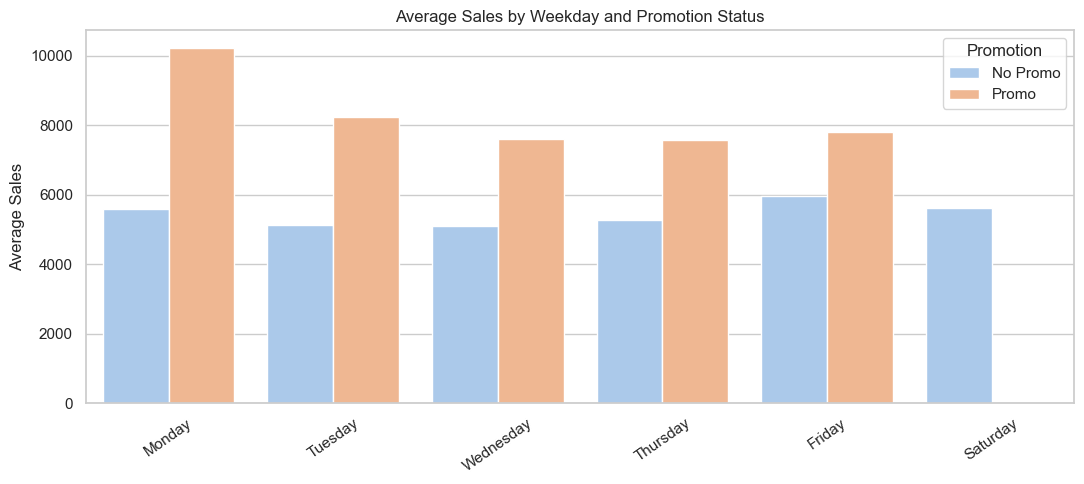

In [6]:
promo_by_weekday = (
    open_sales.groupby(['DayOfWeek', 'Promo'])
    .agg(
        Average_Sales=('Sales', 'mean'),
        Average_Customers=('Customers', 'mean'),
        Sales_per_Customer=('SalesPerCustomer', 'mean'),
        Store_Days=('Sales', 'size')
    )
    .reset_index()
)
promo_by_weekday['Day'] = promo_by_weekday['DayOfWeek'].map(weekday_labels)
promo_by_weekday['Promotion'] = promo_by_weekday['Promo'].map({0: 'No Promo', 1: 'Promo'})

plot_order = [
    weekday_labels[d]
    for d in weekday_order
    if d in promo_by_weekday['DayOfWeek'].unique()
]

plt.figure(figsize=(11, 5))
sns.barplot(
    data=promo_by_weekday,
    x='Day',
    y='Average_Sales',
    hue='Promotion',
    order=plot_order
)
plt.title('Average Sales by Weekday and Promotion Status')
plt.xlabel('')
plt.ylabel('Average Sales')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

## 5. Holiday Effect

Holiday analysis separates state holidays from school holidays. The main comparison uses open-store days, because holiday sales can otherwise be driven by whether stores are open rather than by customer demand.

The number of observations is shown alongside every average. Some holiday categories may have few or no open-store observations, so those results should be treated cautiously.

In [7]:
holiday_order = ['0', 'a', 'b', 'c']

state_holiday_summary = (
    open_sales.groupby(['StateHoliday', 'HolidayType'])
    .agg(
        Average_Sales=('Sales', 'mean'),
        Average_Customers=('Customers', 'mean'),
        Sales_per_Customer=('SalesPerCustomer', 'mean'),
        Open_Store_Days=('Sales', 'size')
    )
    .reset_index()
)
state_holiday_summary['Holiday_Order'] = state_holiday_summary['StateHoliday'].map(
    {value: index for index, value in enumerate(holiday_order)}
)
state_holiday_summary = state_holiday_summary.sort_values('Holiday_Order')
normal_holiday_sales = state_holiday_summary.loc[
    state_holiday_summary['StateHoliday'].eq('0'), 'Average_Sales'
].iloc[0]
state_holiday_summary['Sales_Impact_vs_No_Holiday_%'] = (
    state_holiday_summary['Average_Sales'] / normal_holiday_sales - 1
) * 100

school_holiday_summary = (
    open_sales.groupby('SchoolHoliday')
    .agg(
        Average_Sales=('Sales', 'mean'),
        Average_Customers=('Customers', 'mean'),
        Sales_per_Customer=('SalesPerCustomer', 'mean'),
        Open_Store_Days=('Sales', 'size')
    )
    .reindex([0, 1])
    .reset_index()
)
school_holiday_summary['Holiday'] = school_holiday_summary['SchoolHoliday'].map(
    {0: 'No School Holiday', 1: 'School Holiday'}
)
normal_school_sales = school_holiday_summary.loc[
    school_holiday_summary['SchoolHoliday'].eq(0), 'Average_Sales'
].iloc[0]
school_holiday_summary['Sales_Impact_vs_No_School_Holiday_%'] = (
    school_holiday_summary['Average_Sales'] / normal_school_sales - 1
) * 100

print('State holiday summary')
display(
    state_holiday_summary[
        [
            'StateHoliday',
            'HolidayType',
            'Average_Sales',
            'Average_Customers',
            'Sales_per_Customer',
            'Sales_Impact_vs_No_Holiday_%',
            'Open_Store_Days'
        ]
    ].round(2)
)

print('School holiday summary')
display(
    school_holiday_summary[
        [
            'SchoolHoliday',
            'Holiday',
            'Average_Sales',
            'Average_Customers',
            'Sales_per_Customer',
            'Sales_Impact_vs_No_School_Holiday_%',
            'Open_Store_Days'
        ]
    ].round(2)
)

State holiday summary


,StateHoliday,HolidayType,Average_Sales,Average_Customers,Sales_per_Customer,Sales_Impact_vs_No_Holiday_%,Open_Store_Days
0,0,No Holiday,6748.51,589.00,11.35,0.00,166563
1,a,Public Holiday,7478.96,676.88,10.98,10.82,56


School holiday summary


,SchoolHoliday,Holiday,Average_Sales,Average_Customers,Sales_per_Customer,Sales_Impact_vs_No_School_Holiday_%,Open_Store_Days
0,0,No School Holiday,6688.98,584.77,11.33,0.00,134360
1,1,School Holiday,6997.73,606.75,11.42,4.62,32259


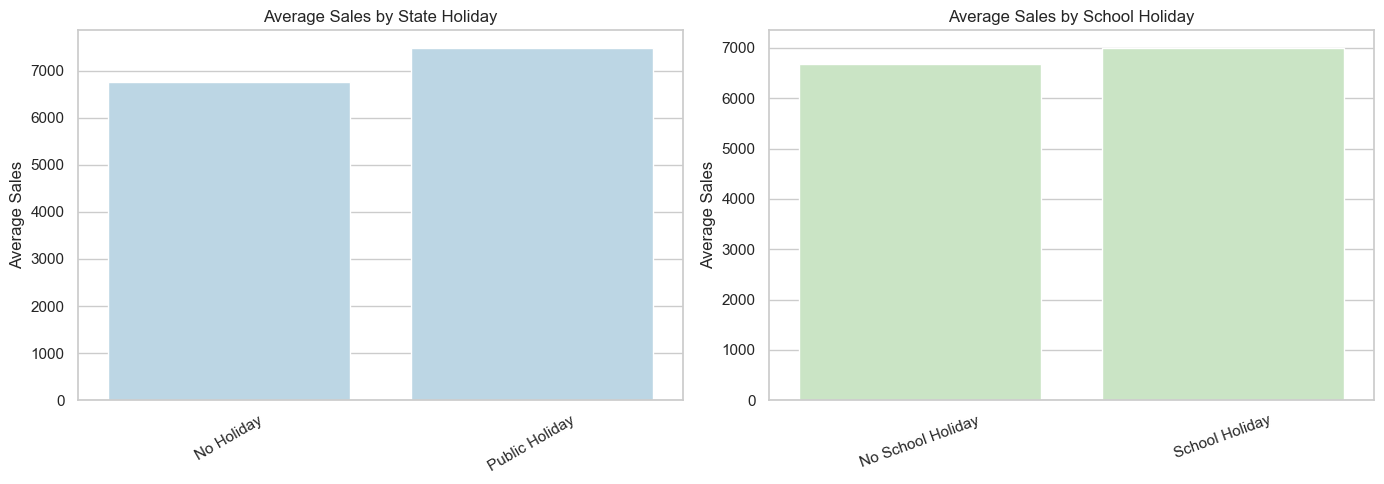

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_state = state_holiday_summary.dropna(subset=['Average_Sales'])
sns.barplot(
    data=plot_state,
    x='HolidayType',
    y='Average_Sales',
    ax=axes[0],
    color='#b5d8eb'
)
axes[0].set_title('Average Sales by State Holiday')
axes[0].set_xlabel('')
axes[0].set_ylabel('Average Sales')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(
    data=school_holiday_summary,
    x='Holiday',
    y='Average_Sales',
    ax=axes[1],
    color='#c7e9c0'
)
axes[1].set_title('Average Sales by School Holiday')
axes[1].set_xlabel('')
axes[1].set_ylabel('Average Sales')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 6. Store Comparison

Store-level analysis identifies performance differences and provides benchmarks for operational planning. The comparison includes average sales, customer volume, total sales, and sales per customer.

Store-type comparisons are descriptive. They do not control for location, competition, assortment, or store size.

In [9]:
store_summary = (
    open_sales.groupby(['Store', 'StoreType', 'Assortment'])
    .agg(
        Average_Sales=('Sales', 'mean'),
        Average_Customers=('Customers', 'mean'),
        Total_Sales=('Sales', 'sum'),
        Total_Customers=('Customers', 'sum'),
        Open_Days=('Sales', 'size')
    )
    .reset_index()
)
store_summary['Sales_per_Customer'] = (
    store_summary['Total_Sales'] / store_summary['Total_Customers']
)
store_summary = store_summary.sort_values('Average_Sales', ascending=False)

store_type_summary = (
    open_sales.groupby('StoreType')
    .agg(
        Average_Sales=('Sales', 'mean'),
        Average_Customers=('Customers', 'mean'),
        Total_Sales=('Sales', 'sum'),
        Total_Customers=('Customers', 'sum'),
        Stores=('Store', 'nunique'),
        Open_Days=('Sales', 'size')
    )
    .reset_index()
)
store_type_summary['Sales_per_Customer'] = (
    store_type_summary['Total_Sales'] / store_type_summary['Total_Customers']
)

print('Top stores by average sales')
display(store_summary.head(10).round(2))

print('Store-type comparison')
display(store_type_summary.round(2))

Top stores by average sales


,Store,StoreType,Assortment,Average_Sales,Average_Customers,Total_Sales,Total_Customers,Open_Days,Sales_per_Customer
59,261,d,c,12616.49,948.93,9828244,739220,779,13.30
132,640,d,c,11533.98,879.51,8984969,685137,779,13.11
51,234,d,a,11072.32,1024.72,8625334,798258,779,10.81
110,528,a,c,10704.44,955.45,8338762,744295,779,11.20
114,545,a,c,10635.26,1026.82,8284865,799891,779,10.36
58,252,d,c,10615.51,809.63,8269484,630702,779,13.11
14,64,d,c,10359.53,792.85,8070070,617633,779,13.07
222,1112,c,c,10236.58,838.61,7974294,653276,779,12.21
39,178,d,a,10089.93,923.57,7870142,720381,780,10.92
217,1101,d,c,9972.27,988.45,7818257,774945,784,10.09


Store-type comparison


,StoreType,Average_Sales,Average_Customers,Total_Sales,Total_Customers,Stores,Open_Days,Sales_per_Customer
0,a,6539.29,611.95,319065151,29858290,65,48792,10.69
1,c,5908.49,545.16,68059943,6279724,15,11519,10.84
2,d,6935.94,583.26,737345465,62005194,143,106308,11.89


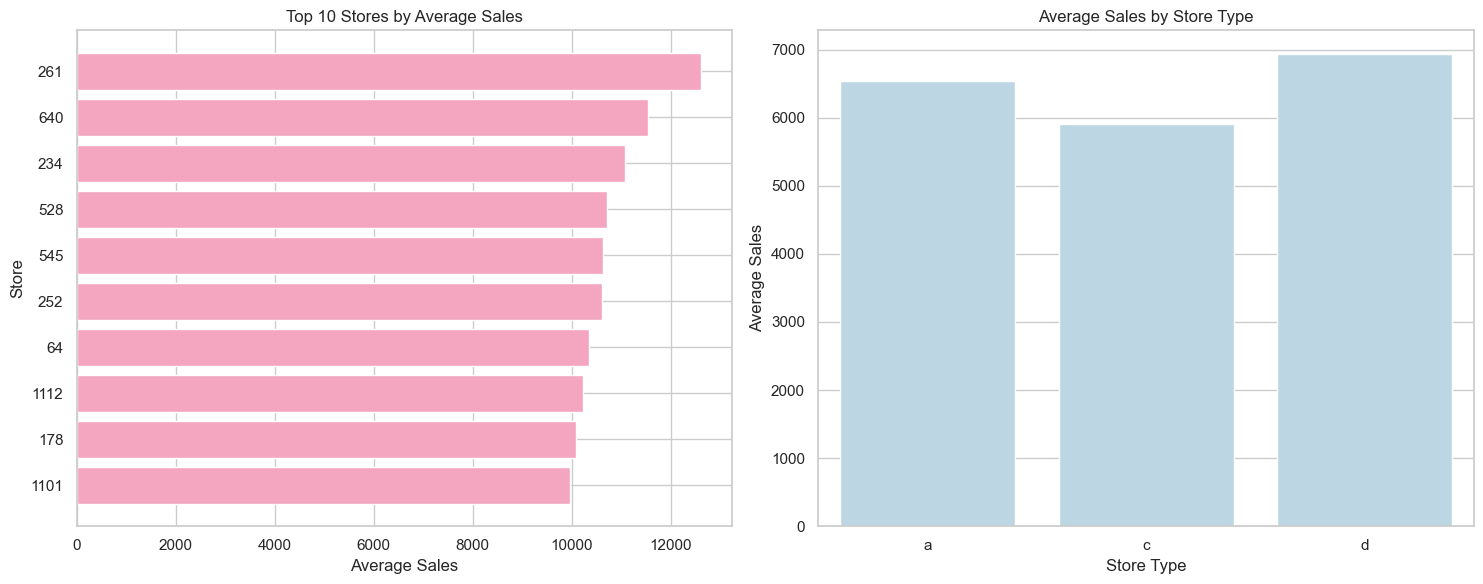

In [10]:
top_stores = store_summary.head(10).sort_values('Average_Sales')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(
    top_stores['Store'].astype(str),
    top_stores['Average_Sales'],
    color='#f4a6c1'
)
axes[0].set_title('Top 10 Stores by Average Sales')
axes[0].set_xlabel('Average Sales')
axes[0].set_ylabel('Store')

sns.barplot(
    data=store_type_summary,
    x='StoreType',
    y='Average_Sales',
    ax=axes[1],
    color='#b5d8eb'
)
axes[1].set_title('Average Sales by Store Type')
axes[1].set_xlabel('Store Type')
axes[1].set_ylabel('Average Sales')

plt.tight_layout()
plt.show()

## 7. Business Recommendations

The recommendations below translate the observed patterns into practical actions. They should be treated as planning hypotheses and tested against operational constraints and future performance.

- Use weekday demand patterns to plan staffing, inventory, and delivery capacity.
- Prioritise promotional activity on high-demand weekdays, then check whether the additional sales also improve margin.
- Treat school-holiday and public-holiday differences as planning signals, while checking store opening status and observation counts.
- Use high-performing stores as benchmarks for further investigation rather than assuming that store type alone explains performance.
- Track sales per customer alongside total sales so that volume growth is not confused with stronger customer productivity.

In [11]:
top_weekday = weekday_summary.loc[weekday_summary['Average_Sales'].idxmax()]
bottom_weekday = weekday_summary.loc[weekday_summary['Average_Sales'].idxmin()]
public_holiday = state_holiday_summary.loc[
    state_holiday_summary['StateHoliday'].eq('a')
].iloc[0]
school_holiday = school_holiday_summary.loc[
    school_holiday_summary['SchoolHoliday'].eq(1)
].iloc[0]
top_store = store_summary.iloc[0]
top_store_type = store_type_summary.loc[
    store_type_summary['Average_Sales'].idxmax()
]

top_day_name = top_weekday['Day']
bottom_day_name = bottom_weekday['Day']
top_store_id = int(top_store['Store'])
top_store_type_name = top_store_type['StoreType']

print(
    f'1. Weekday planning: {top_day_name} has the highest average sales '
    f'({top_weekday["Average_Sales"]:,.0f}), while {bottom_day_name} '
    f'has the lowest ({bottom_weekday["Average_Sales"]:,.0f}).'
)
print(
    f'2. Promotion planning: matched store-weekday promotion uplift is '
    f'{promo_pairs["Uplift_%"].mean():.1f}% across {len(promo_pairs):,} pairs. '
    'Prioritise high-demand weekdays and monitor margin, not sales alone.'
)
print(
    f'3. Holiday planning: open public-holiday days are '
    f'{public_holiday["Sales_Impact_vs_No_Holiday_%"]:.1f}% above '
    'non-holiday open days, while school-holiday days are '
    f'{school_holiday["Sales_Impact_vs_No_School_Holiday_%"]:.1f}% above '
    'non-school-holiday days.'
)
print(
    f'4. Store benchmarking: Store {top_store_id} has the highest '
    f'average sales ({top_store["Average_Sales"]:,.0f}); store type '
    f'{top_store_type_name} has the highest average sales among types.'
)

1. Weekday planning: Monday has the highest average sales (8,200), while Saturday has the lowest (5,631).
2. Promotion planning: matched store-weekday promotion uplift is 54.0% across 1,115 pairs. Prioritise high-demand weekdays and monitor margin, not sales alone.
3. Holiday planning: open public-holiday days are 10.8% above non-holiday open days, while school-holiday days are 4.6% above non-school-holiday days.
4. Store benchmarking: Store 261 has the highest average sales (12,616); store type d has the highest average sales among types.


## 8. Conclusion and Limitations

The analysis shows a clear weekday pattern, a substantial observed association between promotions and sales, modestly positive school-holiday differences, and meaningful variation across stores and store types.

The strongest practical opportunities are to prepare more capacity for high-demand weekdays, evaluate promotions using matched comparisons, and use high-performing stores as benchmarks for investigation rather than assuming their performance is caused by store type alone.

Important limitations:

- This file is a selected-store subset rather than the complete Rossmann chain.
- Main comparisons use open-store days, so they describe sales conditional on being open.
- Promotion and holiday comparisons are observational and may reflect seasonality, store mix, or other confounding factors.
- Easter and Christmas holiday categories may have few or no open-store observations, so missing results should remain unavailable rather than being interpreted as zero impact.
- A stronger follow-up would use regression or a panel design with store and date controls to estimate adjusted effects.